In [1]:
import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.coord

In [2]:
fourbar = iris.load('/data/cluster4/jj22956/thunderstruck_files/thunderstruck-hab1_4bar-m09.nc?download=1')
air_tempp = fourbar[6]

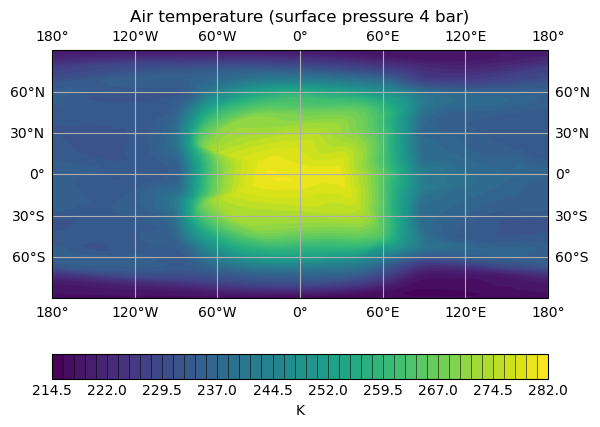

In [3]:
qplt.contourf(air_tempp[0], 50)

plt.gca().gridlines(draw_labels=True)
plt.title('Air temperature (surface pressure 4 bar)')
plt.show()

In [4]:
air_tempp_roll = aeolus.coord.roll_cube_pm180(air_tempp, add_shift=0)
air_tempp_roll[0].ndim
air_tempp_roll0 = air_tempp_roll[0]

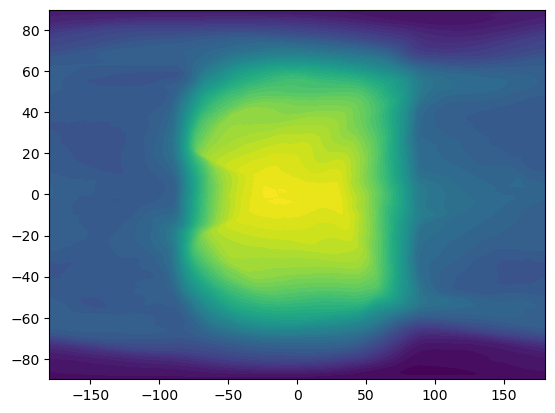

In [5]:
# contour = iplt.contour(air_tempp_roll[0])

x = air_tempp_roll0.coord('longitude').points
y = air_tempp_roll0.coord('latitude').points

data = air_tempp_roll0.data

X, Y = np.meshgrid(x, y)

plt.contourf(x, y, data, 50)

# plt.gca().gridlines(draw_labels=True)
plt.show()

In [6]:
dayside = air_tempp_roll.extract(iris.Constraint(longitude=lambda v:  (-75<= v <= 75)))
# dayside.ndim

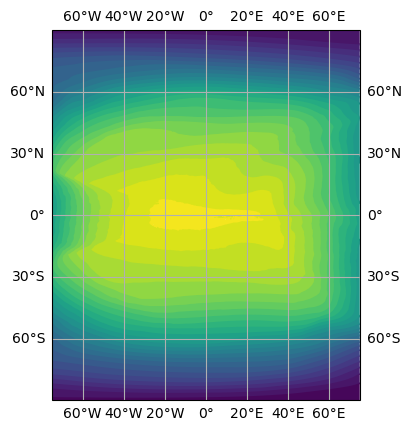

In [7]:
iplt.contourf(dayside[0], 25)

plt.gca().gridlines(draw_labels=True)
plt.show()

In [8]:
# dayside.coord('latitude').guess_bounds()
# dayside.coord('longitude').guess_bounds()
# grid_areas = iris.analysis.cartography.area_weights(dayside)

In [9]:
new_dayside = dayside.collapsed(['longitude', 'latitude'], iris.analysis.MEAN)

/home/jj22956/.local/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'longitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'longitude'. Ignoring bounds.
  warnings.warn(


In [10]:
print(new_dayside.coord('level_height').points)

[   24.17219899    64.46242232   120.86098999   193.3775939
   282.01221423   386.75518781   507.61617284   644.59516933
   797.68257857   966.88791993  1152.21139174  1353.64312757
  1571.19289468  1804.86074266  2054.63695381  2320.53109708
  2602.54322206  2900.66380938  3214.90242798  3545.25887954
  3891.72419008  4254.30713527  4633.00811174  5027.81769928
  5438.74467357  5865.79012537  6308.94364286  6768.21514205
  7243.60561455  7735.10365694  8242.72017684  8766.46360286
  9306.3443468   9862.42091315 10434.7810586  11023.61566638
 11629.19643523 12251.96016548 12892.54247349 13551.82439693
 14231.02411787 14931.7762909  15656.21632919 16407.07411085
 17187.81627368 18002.7661989  18857.283491   19757.88247408
 20712.46174747 21730.47870764]


In [11]:
sample_points = [('level_height', np.linspace(400, 1250, 10))]
new_column = new_dayside.interpolate(sample_points, iris.analysis.Linear())

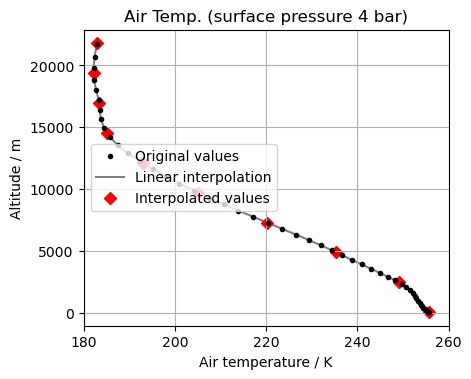

In [12]:
alt_coord = new_dayside.coord("level_height")

# Interpolate the "perfect" linear interpolation. Really this is just
# a high number of interpolation points, in this case 1000 of them.
altitude_points = [
    (
        "level_height",
        np.linspace(min(alt_coord.points), max(alt_coord.points), 1000),
    )
]
scheme = iris.analysis.Linear()
linear_column = new_dayside.interpolate(altitude_points, scheme)

# Now interpolate the data onto 10 evenly spaced altitude levels,
# as we did in the example.
altitude_points = [("level_height", np.linspace(24, 21800, 10))]
scheme = iris.analysis.Linear()
new_column = new_dayside.interpolate(altitude_points, scheme)

plt.figure(figsize=(5, 4), dpi=100)

# Plot the black markers for the original data.
qplt.plot(
    new_dayside,
    marker="o",
    color="black",
    linestyle="",
    markersize=3,
    label="Original values",
    zorder=2,
)

# Plot the gray line to display the linear interpolation.
qplt.plot(
    linear_column,
    color="gray",
    label="Linear interpolation",
    zorder=0,
)

# Plot the red markers for the new data.
qplt.plot(
    new_column,
    marker="D",
    color="red",
    linestyle="",
    label="Interpolated values",
    zorder=1,
)

ax = plt.gca()
# Space the plot such that the labels appear correctly.
plt.subplots_adjust(left=0.17, bottom=0.14)

# Limit the plot to a maximum of 5 ticks.
ax.xaxis.get_major_locator().set_params(nbins=5)

# Prevent matplotlib from using "offset" notation on the xaxis.
ax.xaxis.get_major_formatter().set_useOffset(False)

# Put some space between the line and the axes.
ax.margins(0.05)

# Place gridlines and a legend.
ax.grid()
plt.legend(loc="center left")
plt.title('Air Temp. (surface pressure 4 bar)')
plt.ylabel('Altitude / m')
plt.xlim(180, 260)
plt.show()